In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns 

# Tell matplotlib to show plots inside the notebook
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df = pd.read_csv('creditcard.csv')  # make sure the file is in the same folder as your notebook

# First look at the data
print("Shape:", df.shape)           # how many rows and columns?
print("\nFirst 5 rows:")
df.head()                           # shows first 5 rows

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Shape:", df.shape)         
print("\nColumn names:", df.columns.tolist())
print("\nAny missing values?")
print(df.isnull().sum().sum())       
print("\nData types:")
print(df.dtypes)

Shape: (284807, 31)

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Any missing values?
0

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

As percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


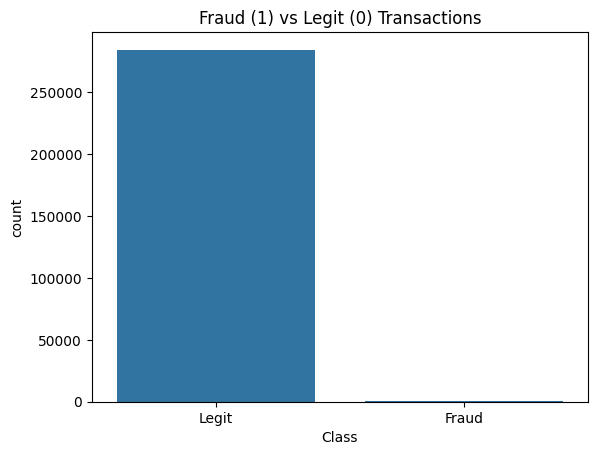

In [4]:
print("Class distribution:")
print(df['Class'].value_counts())

print("\nAs percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title('Fraud (1) vs Legit (0) Transactions')
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.show()

In [5]:
fraud = df[df['Class'] == 1]    
legit = df[df['Class'] == 0]    
print("Fraud transactions - Amount stats:")
print(fraud['Amount'].describe())

print("\nLegit transactions - Amount stats:")
print(legit['Amount'].describe())

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Legit transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


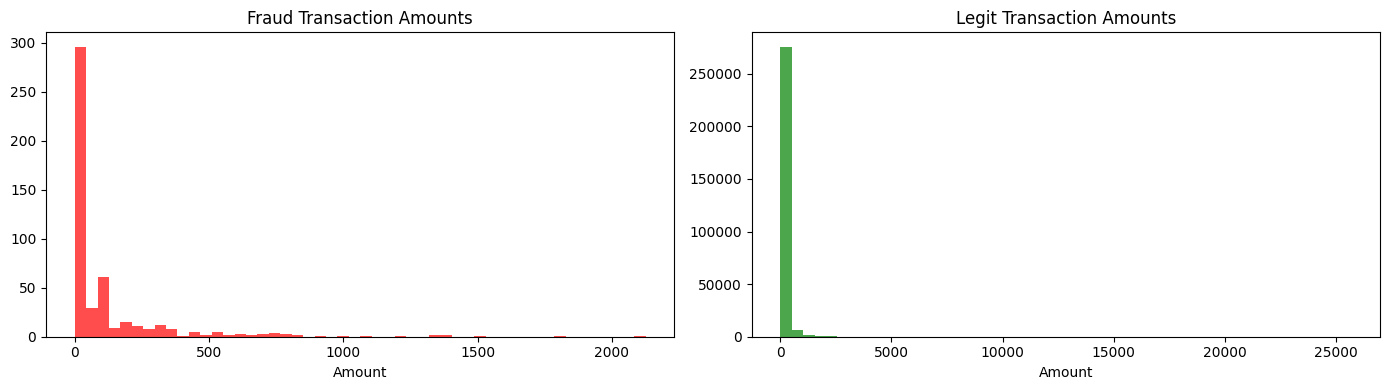

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(fraud['Amount'], bins=50, color='red', alpha=0.7)
axes[0].set_title('Fraud Transaction Amounts')
axes[0].set_xlabel('Amount')

axes[1].hist(legit['Amount'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Legit Transaction Amounts')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

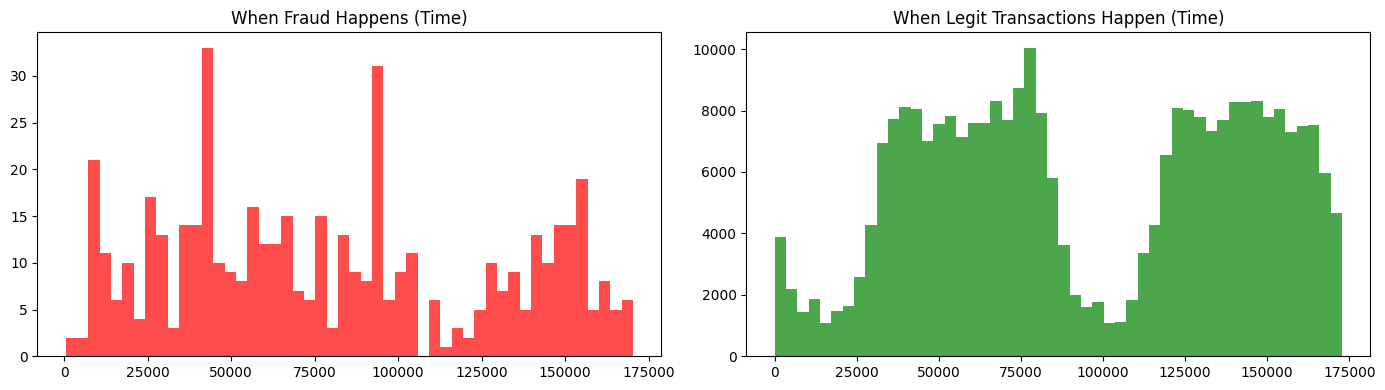

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(fraud['Time'], bins=50, color='red', alpha=0.7)
axes[0].set_title('When Fraud Happens (Time)')

axes[1].hist(legit['Time'], bins=50, color='green', alpha=0.7)
axes[1].set_title('When Legit Transactions Happen (Time)')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

df = df.drop(columns=['Amount', 'Time'])

print("✅ Scaling done!")
print("New shape:", df.shape)
print(df.head())

✅ Scaling done!
New shape: (284807, 30)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024 -0.054952  ... -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  0.753074  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       

In [9]:
X = df.drop(columns=['Class'])  
y = df['Class']                
print("X shape:", X.shape) 
print("y shape:", y.shape)   

print("\nFraud cases in y:", y.sum())   

X shape: (284807, 29)
y shape: (284807,)

Fraud cases in y: 492


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42,
    stratify=y        
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("\nFraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training size: (227845, 29)
Testing size: (56962, 29)

Fraud in training: 394
Fraud in testing: 98


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print("  Legit:", (y_train == 0).sum())
print("  Fraud:", (y_train == 1).sum())

print("\nAfter SMOTE:")
print("  Legit:", (y_train_smote == 0).sum())
print("  Fraud:", (y_train_smote == 1).sum())

Before SMOTE:
  Legit: 227451
  Fraud: 394

After SMOTE:
  Legit: 227451
  Fraud: 227451


In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_lr = lr_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



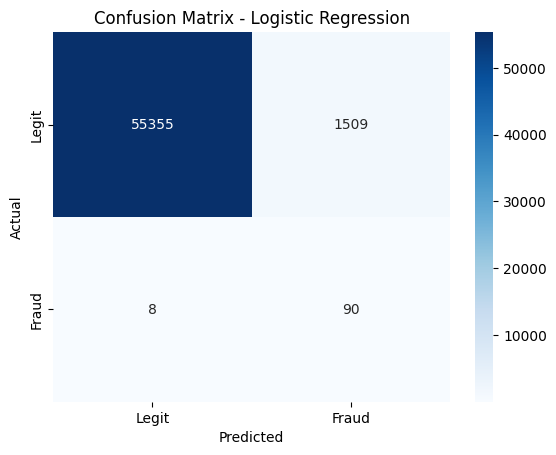

True Negatives (Legit correctly identified): 55355
False Positives (Legit wrongly flagged as Fraud): 1509
False Negatives (Fraud missed): 8
True Positives (Fraud correctly caught): 90


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])

plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("True Negatives (Legit correctly identified):", cm[0][0])
print("False Positives (Legit wrongly flagged as Fraud):", cm[0][1])
print("False Negatives (Fraud missed):", cm[1][0])
print("True Positives (Fraud correctly caught):", cm[1][1])

In [15]:
import sys
!{sys.executable} -m pip install xgboost

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,      # 100 trees
    max_depth=4,           # how deep each tree grows
    learning_rate=0.1,     # how fast it learns
    random_state=42,
    eval_metric='logloss'
)


xgb_model.fit(X_train_smote, y_train_smote)

print("✅ XGBoost trained!")

✅ XGBoost trained!


Classification Report - XGBoost:
              precision    recall  f1-score   support

       Legit       1.00      0.99      1.00     56864
       Fraud       0.16      0.91      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.95      0.63     56962
weighted avg       1.00      0.99      0.99     56962



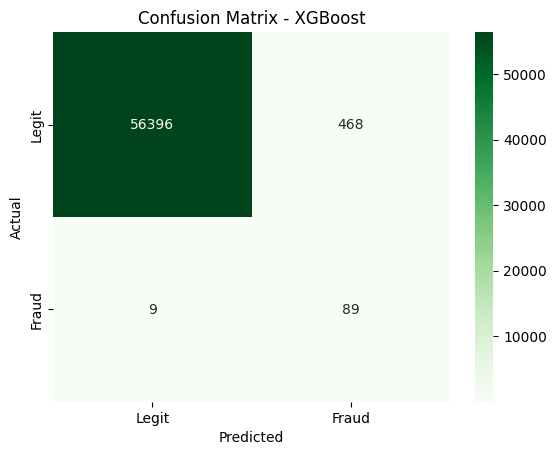


True Negatives: 56396
False Positives: 468
False Negatives: 9
True Positives: 89


In [17]:
y_pred_xgb = xgb_model.predict(X_test)

print("Classification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))


cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])

plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nTrue Negatives:", cm_xgb[0][0])
print("False Positives:", cm_xgb[0][1])
print("False Negatives:", cm_xgb[1][0])
print("True Positives:", cm_xgb[1][1])

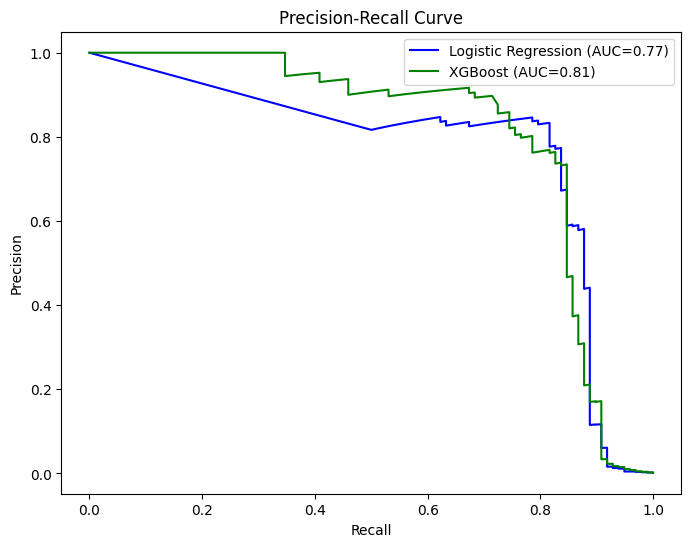

Logistic Regression PR-AUC: 0.77
XGBoost PR-AUC:             0.81


In [18]:
from sklearn.metrics import precision_recall_curve, auc

y_scores_lr = lr_model.predict_proba(X_test)[:, 1]
y_scores_xgb = xgb_model.predict_proba(X_test)[:, 1]

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_scores_lr)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_scores_xgb)

# AUC scores
auc_lr = auc(recall_lr, precision_lr)
auc_xgb = auc(recall_xgb, precision_xgb)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})', color='blue')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AUC={auc_xgb:.2f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

print(f"Logistic Regression PR-AUC: {auc_lr:.2f}")
print(f"XGBoost PR-AUC:             {auc_xgb:.2f}")

C:\Users\hp\AppData\Local\Temp\ipykernel_15796\133287890.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')


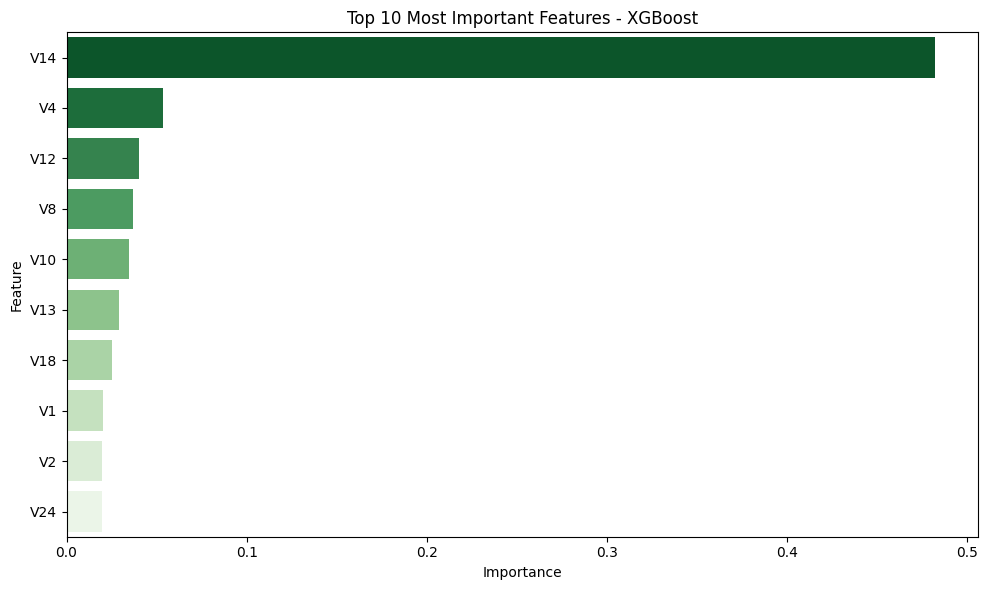

Top 10 features:
   Feature  Importance
13     V14    0.481770
3       V4    0.053271
11     V12    0.040353
7       V8    0.036613
9      V10    0.034601
12     V13    0.029332
17     V18    0.025055
0       V1    0.020034
1       V2    0.019916
23     V24    0.019672


In [19]:
import pandas as pd

# Get feature importances from XGBoost
importance = xgb_model.feature_importances_
feature_names = X.columns

# Put into a DataFrame and sort
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')
plt.title('Top 10 Most Important Features - XGBoost')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_df)

In [23]:

print("   CREDIT CARD FRAUD DETECTION - SUMMARY")


print("\n📦 Dataset:")
print("   Total transactions: 284,807")
print("   Fraud cases: 492 (0.17%)")

print("\n⚙️ Preprocessing:")
print("   - Scaled Amount column")
print("   - Dropped Time column")
print("   - 80/20 train-test split")
print("   - SMOTE applied to balance training data")

print("\n🤖 Models Trained:")
print("   1. Logistic Regression")
print("   2. XGBoost  (Winner)")

print("\n📊 Final Results (XGBoost):")
print("   Fraud Caught:    89 / 98  (91%)")
print("   False Alarms:    468")
print("   PR-AUC Score:    0.81")
print("   Top Feature:     V14 (48% importance)")

print("\n Project Complete!")


   CREDIT CARD FRAUD DETECTION - SUMMARY

📦 Dataset:
   Total transactions: 284,807
   Fraud cases: 492 (0.17%)

⚙️ Preprocessing:
   - Scaled Amount column
   - Dropped Time column
   - 80/20 train-test split
   - SMOTE applied to balance training data

🤖 Models Trained:
   1. Logistic Regression
   2. XGBoost  (Winner)

📊 Final Results (XGBoost):
   Fraud Caught:    89 / 98  (91%)
   False Alarms:    468
   PR-AUC Score:    0.81
   Top Feature:     V14 (48% importance)

 Project Complete!
